<a href="https://colab.research.google.com/github/lalitha-sahitya/Fake-News-Detection/blob/main/Fake_News_Detection_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os

In [3]:
!pip install opendatasets

In [4]:
import opendatasets as od

In [5]:
od.download('https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset')

Skipping, found downloaded files in "./fake-and-real-news-dataset" (use force=True to force download)


In [6]:
os.listdir('fake-and-real-news-dataset')

['True.csv', 'Fake.csv']

In [7]:
import pandas as pd
import numpy as np

In [8]:
fake=pd.read_csv('/content/fake-and-real-news-dataset/Fake.csv')
true=pd.read_csv('/content/fake-and-real-news-dataset/True.csv')

In [9]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [10]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [11]:
fake.isna().sum()

,0
title,0
text,0
subject,0
date,0


In [12]:
true.isna().sum()

,0
title,0
text,0
subject,0
date,0


In [13]:
fake['category']=1
true['category']=0

In [14]:
fake.subject.value_counts()

,count
subject,
News,9050
politics,6841
left-news,4459
Government News,1570
US_News,783
Middle-east,778


In [15]:
true.subject.value_counts()

,count
subject,
politicsNews,11272
worldnews,10145


In [16]:
df=pd.concat([fake,true],axis=0)

In [17]:
df.head()

,title,text,subject,date,category
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


In [18]:
df.tail()

,title,text,subject,date,category
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",0
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",0
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",0
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",0
21416,Indonesia to buy $1.14 billion worth of Russia...,JAKARTA (Reuters) - Indonesia will buy 11 Sukh...,worldnews,"August 22, 2017",0


In [19]:
df=df.drop(['title','date','subject'],axis=1)
df.head()

,text,category
0,Donald Trump just couldn t wish all Americans ...,1
1,House Intelligence Committee Chairman Devin Nu...,1
2,"On Friday, it was revealed that former Milwauk...",1
3,"On Christmas day, Donald Trump announced that ...",1
4,Pope Francis used his annual Christmas Day mes...,1


In [20]:
df.isna().sum()

,0
text,0
category,0


In [21]:
x=df['text']
y=df['category']

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [24]:
x_train.shape

(35918,)

In [25]:
x_test.shape

(8980,)

In [26]:
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer()

In [27]:
x_train=cv.fit_transform(x_train)

In [28]:
x_test=cv.transform(x_test)

In [32]:
x_train[0].toarray()

array([[0, 0, 0, ..., 0, 0, 0]])

In [33]:
from sklearn.naive_bayes import MultinomialNB
nb=MultinomialNB()
nb.fit(x_train,y_train)

MultinomialNB()

In [35]:
preds=nb.predict(x_test)

In [36]:
preds

array([1, 0, 0, ..., 0, 0, 1])

In [38]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,preds)

0.9522271714922049

In [41]:
from sklearn.metrics import confusion_matrix
cf=confusion_matrix(y_test,preds)

<Axes: >

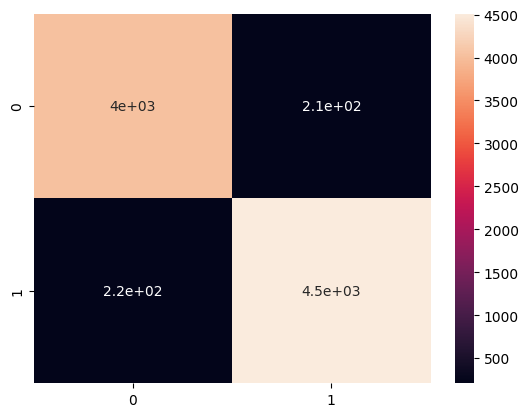

In [42]:
sns.heatmap(cf,annot=True)